# Multiview Robot Capture EDA — Input/Output Bias Analysis

**목표**: Shared Encoder Autoencoder에 입력될 multiview 이미지 데이터셋의 편향(bias)을 전통적 CV 기법으로 분석한다.

핵심 질문
- **입력 편향**: 각 뷰(left/center/right)에서 플러그/포트가 이미지 내 특정 위치에 몰려있는가? 위상(phase)별로 시각적 분포가 다른가?
- **출력 편향**: 액션(tip_error, z_offset, force)의 분포가 균형적인가, 아니면 특정 범위에 편중되어 있는가?
- **뷰 간 중복성**: left/center/right가 실질적으로 다른 정보를 제공하는가?

분석 구조
1. Setup & 데이터 카탈로그
2. 출력 공간 편향 분석 (phase, tip_error, action position, force/torque)
3. 입력 공간 편향 분석 (색상 통계, 공간 히트맵, 위상별 차이)
4. 뷰 간 일관성 분석 (cross-view correlation, PCA)
5. 세션 다양성 분석 (nic vs sc, rail별)
6. 요약 및 데이터 큐레이션 권고

In [9]:
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 캐시 삭제 후 재로드 (최초 1회만 필요)
import shutil
shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)
fm._load_fontmanager(try_read_cache=False)

# 폰트 등록
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('font:', plt.rcParams['font.family'])

Could not save font_manager cache [Errno 2] No such file or directory: '/home/vsc/.cache/matplotlib/fontlist-v390.json.matplotlib-lock'


font: ['NanumGothic']


In [10]:

# ── Section 0: Setup ──────────────────────────────────────────────────────────
from __future__ import annotations

import json
import math
import os
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

CAPTURES_DIR = Path('/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/captures')
VIEWS = ['left', 'center', 'right']
PHASES = ['approach', 'insert', 'stabilize']

# 유효 세션만 사용 (steps.jsonl이 있는 것)
ALL_SESSIONS = sorted([
    p for p in CAPTURES_DIR.iterdir()
    if p.is_dir() and (p / 'steps.jsonl').exists()
])
print(f'유효 세션 수: {len(ALL_SESSIONS)}')
print([s.name for s in ALL_SESSIONS[:3]], '...')

유효 세션 수: 42
['20260418_131831_nic_rail0_task_1', '20260418_132002_nic_rail1_task_1', '20260418_132134_nic_rail2_task_1'] ...


In [11]:

# ── Section 1: 데이터 카탈로그 ─────────────────────────────────────────────────
def parse_session_name(session_dir: Path) -> dict:
    name = session_dir.name  # e.g. 20260418_131831_nic_rail0_task_1
    parts = name.split('_')
    task_type = parts[2]          # nic or sc
    rail = parts[3]               # rail0 ~ rail4
    return {
        'session': name,
        'task_type': task_type,
        'rail': rail,
        'session_dir': session_dir,
    }

catalog_rows = []
for sess_dir in ALL_SESSIONS:
    info = parse_session_name(sess_dir)
    ep_path = sess_dir / 'episode_summary.json'
    if ep_path.exists():
        ep = json.loads(ep_path.read_text())
        info['status'] = ep.get('status', 'unknown')
        psc = ep.get('phase_step_counts', {})
        info['n_approach'] = psc.get('approach', 0)
        info['n_insert'] = psc.get('insert', 0)
        info['n_stabilize'] = psc.get('stabilize', 0)
        info['n_steps'] = sum(psc.values())
    else:
        n = sum(1 for _ in open(sess_dir / 'steps.jsonl'))
        info['status'] = 'no_summary'
        info['n_steps'] = n
        info['n_approach'] = info['n_insert'] = info['n_stabilize'] = None

    # 이미지 수 확인 (center 기준)
    imgs = list((sess_dir / 'images' / 'center').glob('*.png'))
    info['n_images'] = len(imgs)

    # 이미지 해상도 (첫 번째 이미지)
    if imgs:
        img = Image.open(sorted(imgs)[0])
        info['img_w'], info['img_h'] = img.size
    catalog_rows.append(info)

catalog_df = pd.DataFrame(catalog_rows)
print('전체 세션:', len(catalog_df))
display(catalog_df[['session', 'task_type', 'rail', 'status', 'n_steps', 'n_approach', 'n_insert', 'n_stabilize', 'n_images', 'img_w', 'img_h']])


전체 세션: 42


,session,task_type,rail,status,n_steps,n_approach,n_insert,n_stabilize,n_images,img_w,img_h
0,20260418_131831_nic_rail0_task_1,nic,rail0,completed,531,100,430,1,531,1152,1024
1,20260418_132002_nic_rail1_task_1,nic,rail1,completed,531,100,430,1,531,1152,1024
2,20260418_132134_nic_rail2_task_1,nic,rail2,completed,531,100,430,1,531,1152,1024
3,20260418_132304_nic_rail3_task_1,nic,rail3,completed,531,100,430,1,531,1152,1024
4,20260418_132437_nic_rail4_task_1,nic,rail4,completed,531,100,430,1,531,1152,1024
5,20260418_132611_sc_rail0_task_1,sc,rail0,completed,531,100,430,1,531,1152,1024
6,20260418_132741_sc_rail1_task_1,sc,rail1,completed,531,100,430,1,531,1152,1024
7,20260418_142819_nic_rail0_task_1,nic,rail0,completed,531,100,430,1,531,1152,1024
8,20260418_142948_nic_rail1_task_1,nic,rail1,completed,531,100,430,1,531,1152,1024
9,20260418_143119_nic_rail2_task_1,nic,rail2,completed,531,100,430,1,531,1152,1024


## Section 2: 출력 공간(Output Space) 편향 분석

**목적**: 모델이 예측/회귀해야 할 출력값(tip_error, action 위치, force)의 분포가 균형적인지 확인한다.  
편향된 출력 분포 → 모델이 평균값만 출력해도 낮은 loss → overfitting / generalization 실패

In [12]:

# ── 2-1: steps.jsonl 전체 파싱 → scalar 레코드 추출 ────────────────────────────
step_rows = []

for sess_dir in tqdm(ALL_SESSIONS, desc='Parsing steps'):
    sess_info = parse_session_name(sess_dir)
    task_type = sess_info['task_type']
    rail = sess_info['rail']
    session = sess_dir.name

    with open(sess_dir / 'steps.jsonl') as f:
        for line in f:
            d = json.loads(line)
            step = d['step']
            phase = d['phase']
            extras = d.get('extras', {})
            obs = d.get('observation', {})
            transforms = d.get('transforms', {})
            action = d.get('action', {})

            # force / torque
            wrench = obs.get('wrist_wrench', {})
            force = wrench.get('force', {})
            torque = wrench.get('torque', {})

            # controller state
            ctrl = obs.get('controller_state', {})
            tcp_err = ctrl.get('tcp_error', [None]*6)

            # action pose
            act_pose = action.get('pose', {})
            act_pos = act_pose.get('position', {})
            act_ori = act_pose.get('orientation', {})

            # plug / port translation
            plug_t = transforms.get('plug', {}).get('translation', {})
            port_t = transforms.get('port', {}).get('translation', {})
            grip_t = transforms.get('gripper', {}).get('translation', {})

            step_rows.append({
                'session': session,
                'task_type': task_type,
                'rail': rail,
                'step': step,
                'phase': phase,
                # extras
                'tip_x_error': extras.get('tip_x_error'),
                'tip_y_error': extras.get('tip_y_error'),
                'tip_x_error_integrator': extras.get('tip_x_error_integrator'),
                'tip_y_error_integrator': extras.get('tip_y_error_integrator'),
                'z_offset': extras.get('z_offset'),
                'slerp_fraction': extras.get('slerp_fraction'),
                'position_fraction': extras.get('position_fraction'),
                # wrench
                'force_x': force.get('x'), 'force_y': force.get('y'), 'force_z': force.get('z'),
                'torque_x': torque.get('x'), 'torque_y': torque.get('y'), 'torque_z': torque.get('z'),
                # tcp_error (6-DOF)
                'tcp_err_x': tcp_err[0] if len(tcp_err) > 0 else None,
                'tcp_err_y': tcp_err[1] if len(tcp_err) > 1 else None,
                'tcp_err_z': tcp_err[2] if len(tcp_err) > 2 else None,
                # action position
                'act_x': act_pos.get('x'), 'act_y': act_pos.get('y'), 'act_z': act_pos.get('z'),
                # 3D positions
                'plug_x': plug_t.get('x'), 'plug_y': plug_t.get('y'), 'plug_z': plug_t.get('z'),
                'port_x': port_t.get('x'), 'port_y': port_t.get('y'), 'port_z': port_t.get('z'),
                'grip_x': grip_t.get('x'), 'grip_y': grip_t.get('y'), 'grip_z': grip_t.get('z'),
            })

steps_df = pd.DataFrame(step_rows)
print(f'총 step 수: {len(steps_df):,}')
print('Phase 분포:')
display(steps_df.groupby(['task_type', 'phase']).size().rename('count').reset_index())


Parsing steps:   0%|          | 0/42 [00:00<?, ?it/s]

총 step 수: 22,302
Phase 분포:


,task_type,phase,count
0,nic,approach,3000
1,nic,insert,12900
2,nic,stabilize,30
3,sc,approach,1200
4,sc,insert,5160
5,sc,stabilize,12


In [13]:
display(steps_df.head(5))

,session,task_type,rail,step,phase,tip_x_error,tip_y_error,tip_x_error_integrator,tip_y_error_integrator,z_offset,slerp_fraction,position_fraction,force_x,force_y,force_z,torque_x,torque_y,torque_z,tcp_err_x,tcp_err_y,tcp_err_z,act_x,act_y,act_z,plug_x,plug_y,plug_z,port_x,port_y,port_z,grip_x,grip_y,grip_z
0,20260418_131831_nic_rail0_task_1,nic,rail0,0,approach,-0.062664,0.007720,0.0,0.0,0.2,0.00,0.00,0.127637,0.445452,20.933467,0.095136,-0.167814,0.028352,0.001496,0.000955,0.010237,-0.372858,0.193851,0.319197,-0.372859,0.214537,0.265077,-0.435524,0.222257,0.133476,-0.372858,0.193851,0.319197
1,20260418_131831_nic_rail0_task_1,nic,rail0,1,approach,-0.062426,0.007680,0.0,0.0,0.2,0.01,0.01,-0.375061,0.946422,24.860733,0.035943,-0.174809,0.094970,0.000225,-0.000161,-0.006401,-0.373687,0.194162,0.320172,-0.373098,0.214577,0.266469,-0.435524,0.222257,0.133476,-0.373062,0.193878,0.320584
2,20260418_131831_nic_rail0_task_1,nic,rail0,2,approach,-0.062715,0.007306,0.0,0.0,0.2,0.02,0.02,-0.638627,0.657248,22.100220,0.090180,-0.064396,0.124854,-0.001914,-0.000086,-0.039884,-0.373914,0.194782,0.340233,-0.372809,0.214951,0.287859,-0.435524,0.222257,0.133476,-0.372657,0.194221,0.341465
3,20260418_131831_nic_rail0_task_1,nic,rail0,3,approach,-0.064592,0.007377,0.0,0.0,0.2,0.03,0.03,-0.784697,0.567802,21.110592,0.069019,-0.095840,0.071852,-0.003771,0.000647,-0.049697,-0.372590,0.195027,0.377749,-0.370932,0.214880,0.326087,-0.435524,0.222257,0.133476,-0.370644,0.194185,0.380810
4,20260418_131831_nic_rail0_task_1,nic,rail0,4,approach,-0.066998,0.007574,0.0,0.0,0.2,0.04,0.04,-1.319506,0.218972,20.760973,0.053058,0.160000,0.000425,-0.004930,0.000951,-0.056816,-0.370882,0.195213,0.419771,-0.368526,0.214683,0.371471,-0.435524,0.222257,0.133476,-0.368189,0.194086,0.425623


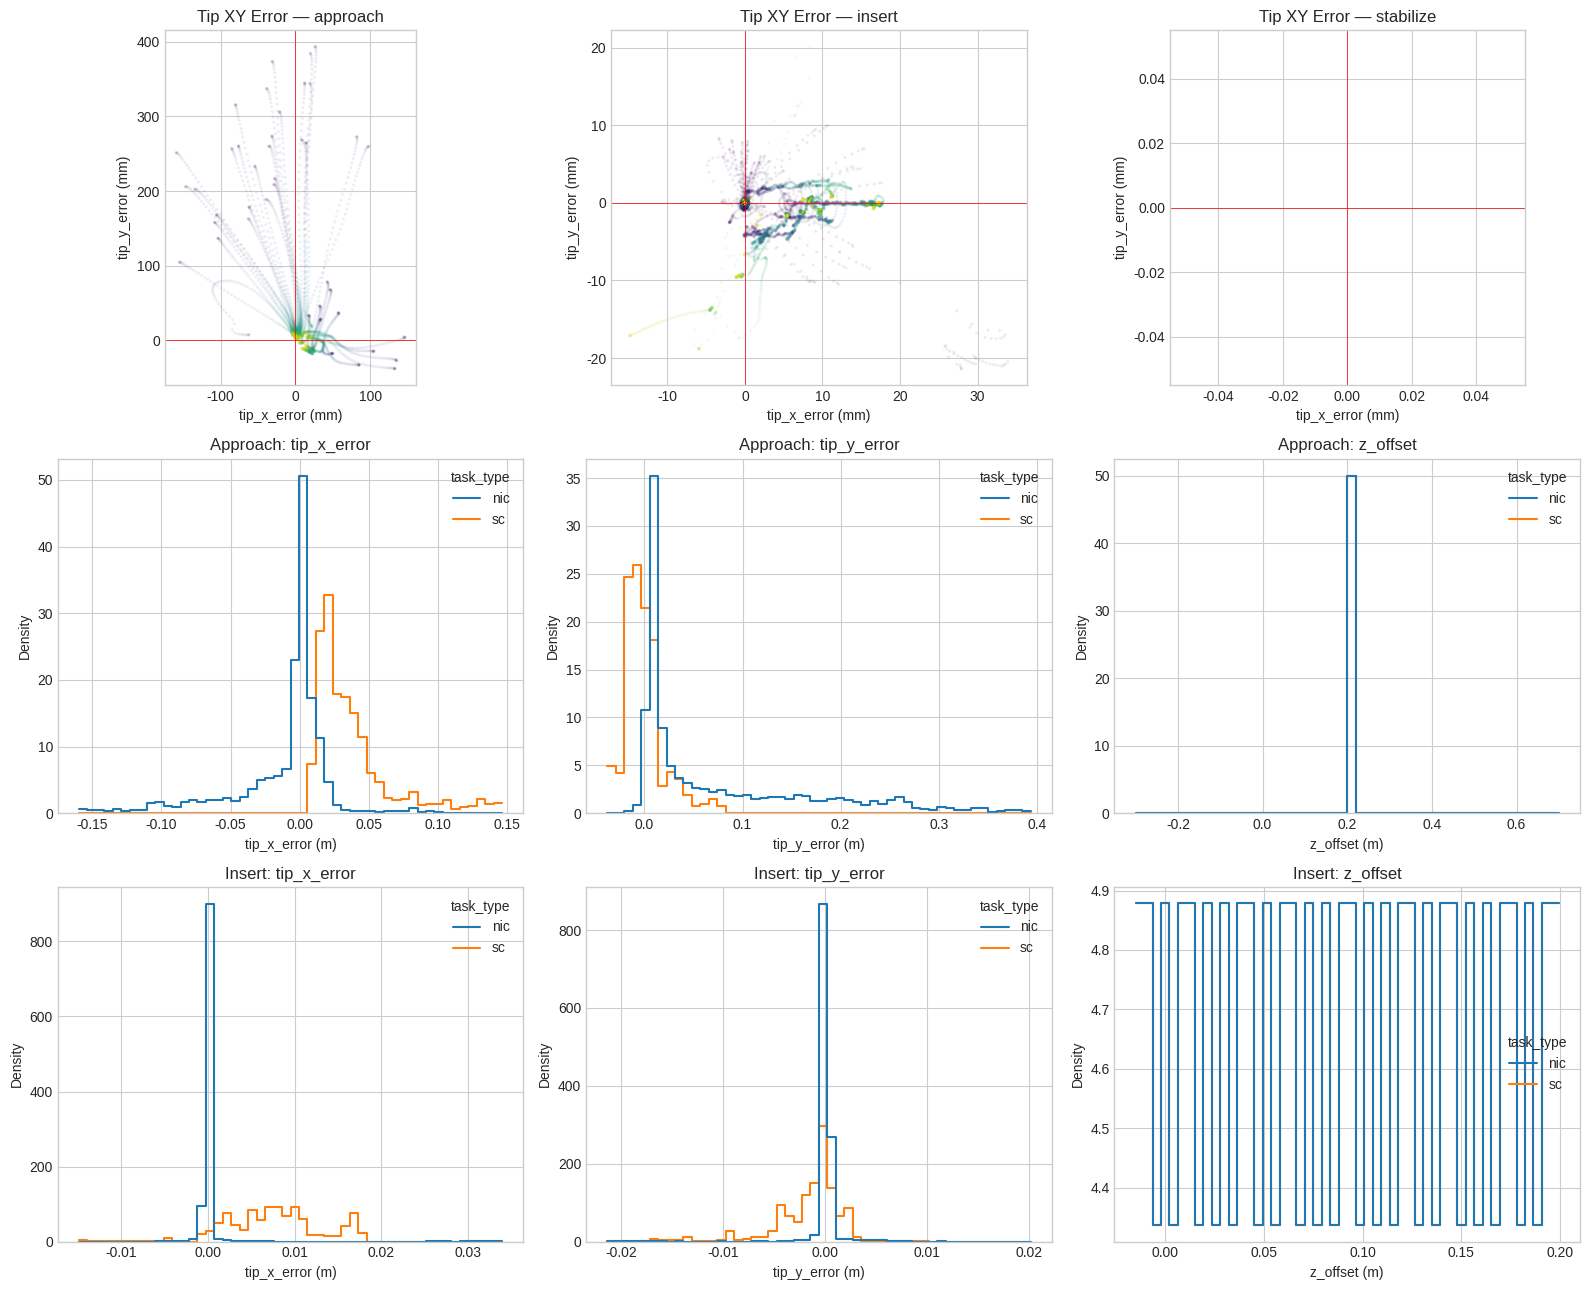


[approach phase] tip_error 통계:


tip_x_error                                                                tip_y_error                                                               
                count     mean      std      min      25%      50%      75%      max       count     mean      std      min      25%      50%      75%      max
task_type                                                                                                                                                      
nic            3000.0 -0.01091  0.03548 -0.15971 -0.01658  0.00028  0.00529  0.09796      3000.0  0.07657  0.09389 -0.01868  0.00797  0.02514  0.12876  0.39370
sc             1200.0  0.03822  0.02913  0.00849  0.01878  0.02876  0.04489  0.14666      1200.0 -0.00021  0.02025 -0.03790 -0.01301 -0.00489  0.00718  0.07852


[insert phase] tip_error 통계:


tip_x_error                                                                tip_y_error                                                               
                count     mean      std      min      25%      50%      75%      max       count     mean      std      min      25%      50%      75%      max
task_type                                                                                                                                                      
nic           12900.0  0.00018  0.00185 -0.00650 -0.00006  0.00009  0.00023  0.03390     12900.0  0.00002  0.00166 -0.02139 -0.00011  0.00006  0.00022  0.02018
sc             5160.0  0.00773  0.00539 -0.01481  0.00424  0.00767  0.01066  0.01786      5160.0 -0.00151  0.00336 -0.01748 -0.00277 -0.00056  0.00026  0.01000

In [14]:
# ── 2-2: tip_error 분포 (핵심 출력 편향 지표) ──────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

approach_df = steps_df[steps_df['phase'] == 'approach'].copy()  # 수정
insert_df   = steps_df[steps_df['phase'] == 'insert'].copy()

# 행 0: 2D scatter (phase별)
for ax, phase in zip(axes[0], ['approach', 'insert', 'stabilize']):
    sub = steps_df[steps_df['phase'] == phase]
    ax.scatter(sub['tip_x_error'] * 1000, sub['tip_y_error'] * 1000,
               alpha=0.05, s=2, c=sub['step'], cmap='viridis')
    ax.set_xlabel('tip_x_error (mm)')
    ax.set_ylabel('tip_y_error (mm)')
    ax.set_title(f'Tip XY Error — {phase}')
    ax.axhline(0, color='red', lw=0.5)
    ax.axvline(0, color='red', lw=0.5)
    ax.set_aspect('equal')

# 행 1: approach 히스토그램
for ax, col, label in zip(axes[1], ['tip_x_error', 'tip_y_error', 'z_offset'],
                          ['tip_x_error (m)', 'tip_y_error (m)', 'z_offset (m)']):
    sns.histplot(data=approach_df, x=col, hue='task_type', bins=50,
                 stat='density', common_norm=False, element='step', fill=False, ax=ax)
    ax.set_xlabel(label)
    ax.set_title(f'Approach: {col}')

# 행 2: insert 히스토그램  ← axes[2]로 수정
for ax, col, label in zip(axes[2], ['tip_x_error', 'tip_y_error', 'z_offset'],
                          ['tip_x_error (m)', 'tip_y_error (m)', 'z_offset (m)']):
    sns.histplot(data=insert_df, x=col, hue='task_type', bins=50,
                 stat='density', common_norm=False, element='step', fill=False, ax=ax)
    ax.set_xlabel(label)
    ax.set_title(f'Insert: {col}')

plt.tight_layout()
plt.show()

# 통계 요약
print('\n[approach phase] tip_error 통계:')
display(approach_df.groupby('task_type')[['tip_x_error', 'tip_y_error']].describe().round(5))
print('\n[insert phase] tip_error 통계:')
display(insert_df.groupby('task_type')[['tip_x_error', 'tip_y_error']].describe().round(5))


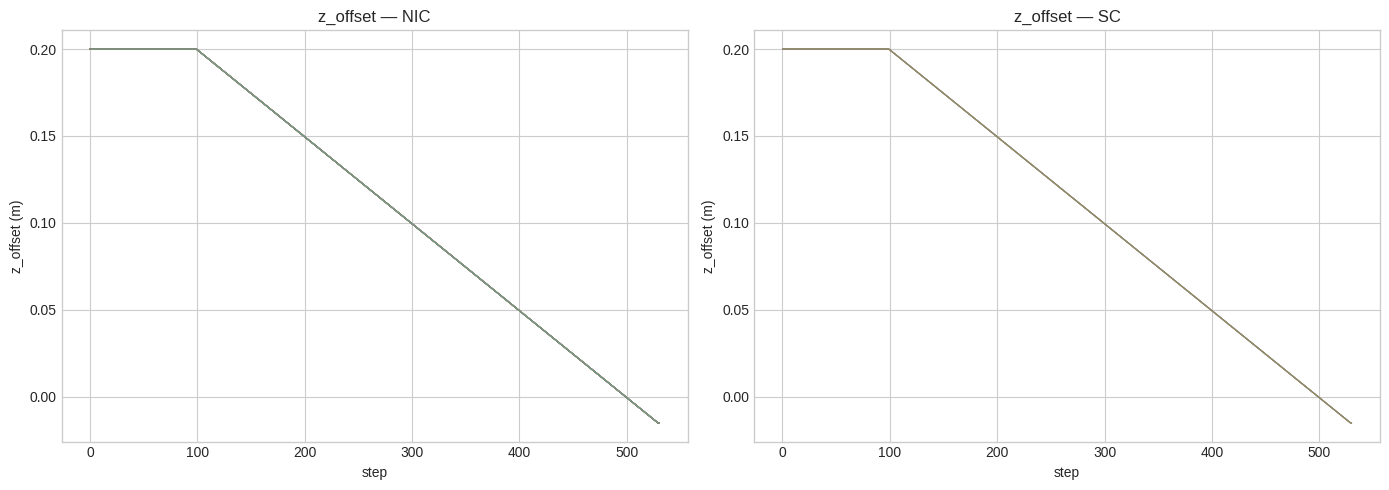

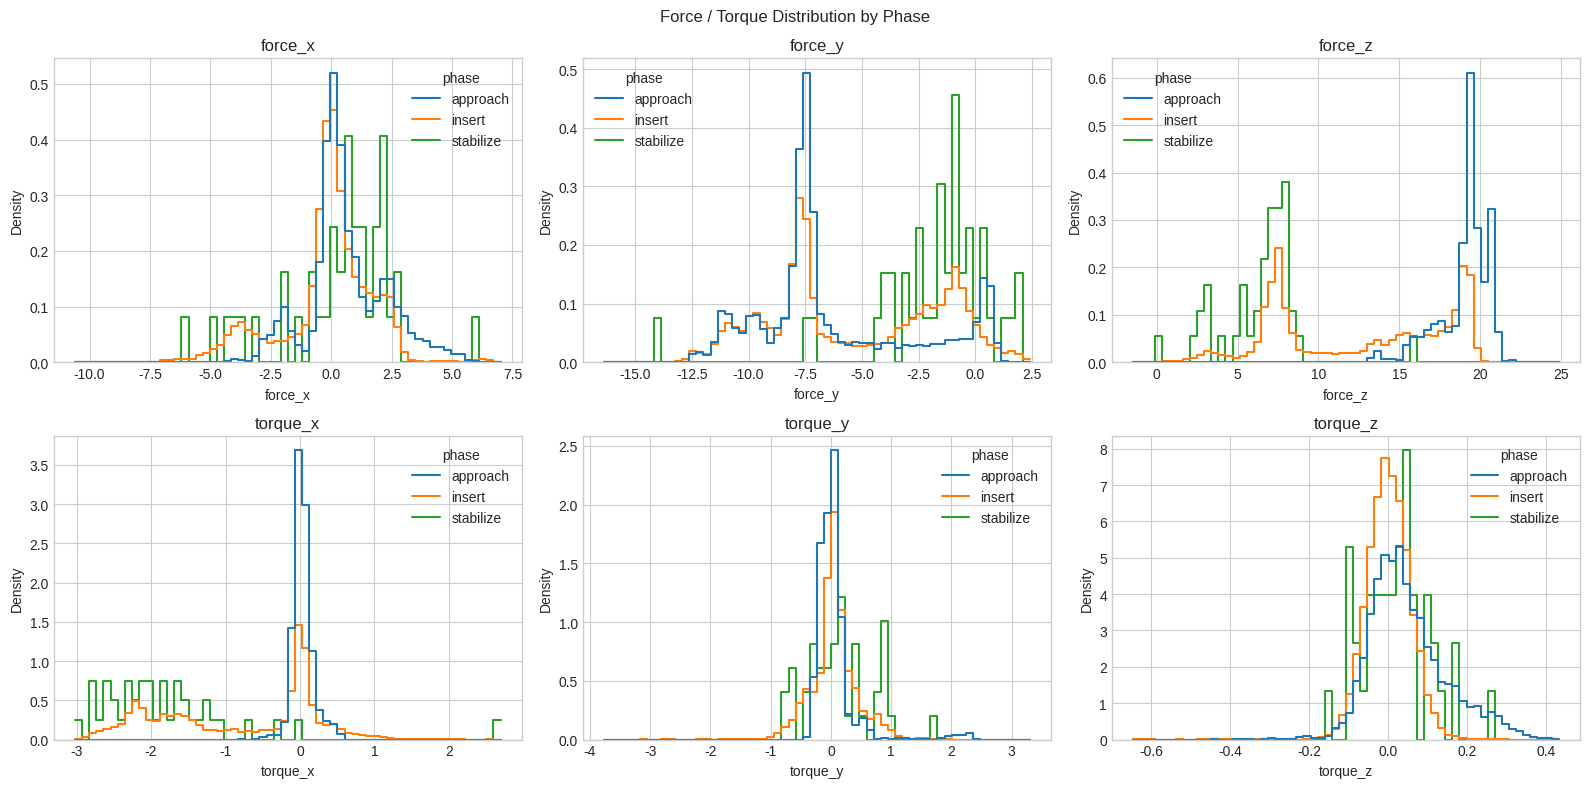


Force 통계 (phase별):


force_x         force_y          force_z         torque_x         torque_y         torque_z        
             mean     std    mean     std     mean     std     mean     std     mean     std     mean     std
phase                                                                                                        
approach   0.6647  1.6374 -6.2746  3.5226  19.0642  1.5371   0.0361  0.1384   0.0565  0.3645   0.0494  0.0994
insert    -0.1691  1.9133 -5.3511  3.7918  12.5719  5.3278  -0.8214  1.0521   0.0515  0.3970   0.0003  0.0560
stabilize  0.2301  2.3822 -1.7849  2.8280   6.4542  2.5153  -1.8110  0.9736   0.1429  0.5532   0.0184  0.0859

In [15]:
# ── 2-3: z_offset 시계열 — 삽입 궤적 일관성 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, ['nic', 'sc']):
    sub = steps_df[steps_df['task_type'] == task]
    for sess, sg in sub.groupby('session'):
        ax.plot(sg['step'], sg['z_offset'], alpha=0.4, lw=0.8)
    ax.set_xlabel('step')
    ax.set_ylabel('z_offset (m)')
    ax.set_title(f'z_offset — {task.upper()}')

plt.tight_layout()
plt.show()

# ── 2-4: Force / Torque 분포 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
force_cols = ['force_x', 'force_y', 'force_z']
torque_cols = ['torque_x', 'torque_y', 'torque_z']

for ax, col in zip(axes[0], force_cols):
    sns.histplot(data=steps_df, x=col, hue='phase', bins=60,
                 stat='density', common_norm=False, element='step', fill=False, ax=ax)
    ax.set_title(col)

for ax, col in zip(axes[1], torque_cols):
    sns.histplot(data=steps_df, x=col, hue='phase', bins=60,
                 stat='density', common_norm=False, element='step', fill=False, ax=ax)
    ax.set_title(col)

plt.suptitle('Force / Torque Distribution by Phase')
plt.tight_layout()
plt.show()

# force 통계 (phase별)
print('\nForce 통계 (phase별):')
display(steps_df.groupby('phase')[force_cols + torque_cols].agg(['mean', 'std']).round(4))


/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3596408/2392353850.py:26: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) mi

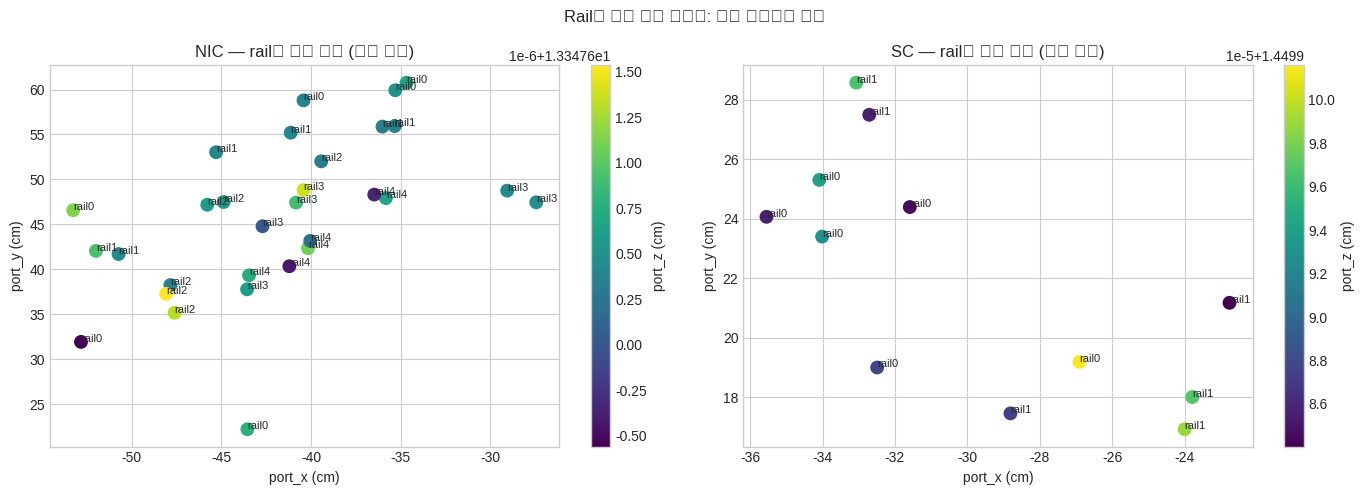


NIC rail 간 포트 거리 (cm):
rail   rail0  rail1  rail2  rail3  rail4
rail                                    
rail0    0.0    3.9    4.4    6.1    4.9
rail1    3.9    0.0    8.0    7.7    8.1
rail2    4.4    8.0    0.0    8.8    6.1
rail3    6.1    7.7    8.8    0.0    3.2
rail4    4.9    8.1    6.1    3.2    0.0

SC rail 간 포트 거리 (cm):
rail   rail0  rail1
rail               
rail0    0.0    5.0
rail1    5.0    0.0


In [17]:
# ── 2-5: rail별 port 위치 다양성 — 데이터 커버리지 확인 ─────────────────────
# 핵심 질문: 각 rail이 공간적으로 얼마나 다른 위치를 커버하는가?
# → rail 다양성 부족 = 모델이 특정 공간 위치에 과적합될 위험

port_mean = (
    steps_df[steps_df['phase'] == 'insert']
    .groupby(['task_type', 'rail', 'session'])[['port_x', 'port_y', 'port_z']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, ['nic', 'sc']):
    sub = port_mean[port_mean['task_type'] == task]
    sc = ax.scatter(sub['port_x'] * 100, sub['port_y'] * 100,
                    c=sub['port_z'] * 100, cmap='viridis', s=80)
    for _, row in sub.iterrows():
        ax.annotate(row['rail'], (row['port_x']*100, row['port_y']*100), fontsize=8)
    plt.colorbar(sc, ax=ax, label='port_z (cm)')
    ax.set_xlabel('port_x (cm)')
    ax.set_ylabel('port_y (cm)')
    ax.set_title(f'{task.upper()} — rail별 포트 위치 (세션 평균)')

plt.suptitle('Rail별 포트 위치 다양성: 공간 커버리지 확인')
plt.tight_layout()
plt.show()

# rail 간 거리 → 가까우면 사실상 동일한 조건 반복
from scipy.spatial.distance import cdist
for task in ['nic', 'sc']:
    sub = port_mean[port_mean['task_type'] == task].groupby('rail')[['port_x','port_y','port_z']].mean()
    dists = cdist(sub.values * 100, sub.values * 100)
    print(f'\n{task.upper()} rail 간 포트 거리 (cm):')
    print(pd.DataFrame(dists, index=sub.index, columns=sub.index).round(1))


## Section 3: 입력 공간(Input Space) 편향 분석

**핵심 질문**: 각 뷰에서 "액션이 일어나는 영역"이 이미지 내 특정 위치에 집중되어 있는가?  
→ 만약 플러그가 항상 이미지 중앙에만 나타난다면, 인코더는 가장자리 정보를 무시하도록 학습될 수 있다.

분석 방법
1. **프레임 차분 히트맵**: |frame_t − frame_{t-1}|의 평균 → 어디서 움직임이 발생하는가
2. **공간 분산 히트맵**: 각 픽셀 위치의 밝기 분산 → 시간에 따라 변화하는 위치
3. **뷰별 평균 이미지**: 시각적 장면 구조 파악
4. **위상별(phase) 색상/밝기 차이**: approach vs insert가 visually 다른가

In [ ]:

# ── 3-1: 이미지 서브샘플링 설정 ─────────────────────────────────────────────────
# 전체 이미지를 분석하면 너무 오래걸리므로 세션당 N 프레임만 샘플링
RESIZE_H, RESIZE_W = 256, 288  # 원본 1024×1152 → 1/4 다운샘플
N_FRAMES_PER_SESSION = 30       # 세션당 균등 샘플링 수

def load_resized_gray(path: Path, h: int = RESIZE_H, w: int = RESIZE_W) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA).astype(np.float32)

def load_resized_rgb(path: Path, h: int = RESIZE_H, w: int = RESIZE_W) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

# steps_df에서 phase 정보를 포함한 이미지 경로 테이블 생성
img_path_rows = []
for sess_dir in ALL_SESSIONS:
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()

    # 균등 샘플링
    indices = np.linspace(0, len(lines) - 1, N_FRAMES_PER_SESSION, dtype=int)
    for idx in indices:
        d = json.loads(lines[idx])
        obs = d.get('observation', {})
        sess_info = parse_session_name(sess_dir)
        for view in VIEWS:
            key = f'{view}_image'
            if key in obs:
                img_path_rows.append({
                    'session': sess_dir.name,
                    'task_type': sess_info['task_type'],
                    'rail': sess_info['rail'],
                    'step': d['step'],
                    'phase': d['phase'],
                    'view': view,
                    'path': Path(obs[key]['path']),
                })

img_path_df = pd.DataFrame(img_path_rows)
print(f'샘플링된 이미지 수: {len(img_path_df):,}')
display(img_path_df.groupby(['view', 'phase']).size().rename('count').reset_index())


In [ ]:

# ── 3-2: 뷰별 평균 이미지 (Mean Image) ─────────────────────────────────────────
# 모든 프레임을 평균하면 → 정적인 배경이 두드러지고, 움직이는 영역은 흐려짐
# 뷰마다 카메라 시점/배경이 얼마나 다른지 직관적으로 확인

mean_images = {}  # (view, task_type) → mean RGB

for (view, task_type), sub in tqdm(img_path_df.groupby(['view', 'task_type']),
                                    desc='Computing mean images'):
    acc = np.zeros((RESIZE_H, RESIZE_W, 3), dtype=np.float64)
    count = 0
    for path in sub['path']:
        try:
            img = load_resized_rgb(path)
            acc += img
            count += 1
        except FileNotFoundError:
            continue
    if count:
        mean_images[(view, task_type)] = (acc / count).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_i, task_type in enumerate(['nic', 'sc']):
    for col_i, view in enumerate(VIEWS):
        ax = axes[row_i][col_i]
        key = (view, task_type)
        if key in mean_images:
            ax.imshow(mean_images[key])
            ax.set_title(f'{task_type.upper()} — {view}')
        ax.axis('off')

plt.suptitle('뷰 × 태스크별 평균 이미지 (Mean Frame)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:

# ── 3-3: 공간 분산 히트맵 (Spatial Variance Heatmap) ───────────────────────────
# 각 픽셀의 밝기 분산 = "이 위치가 얼마나 시간에 따라 변하는가"
# 분산이 높은 곳 = 로봇 팔/플러그가 자주 지나가는 위치
# → 입력 편향의 핵심: 분산이 특정 영역에 몰려 있으면 인코더가 해당 영역에 과적합

var_maps = {}  # (view, task_type) → variance map

for (view, task_type), sub in tqdm(img_path_df.groupby(['view', 'task_type']),
                                    desc='Computing variance maps'):
    frames = []
    for path in sub['path']:
        try:
            gray = load_resized_gray(path)
            frames.append(gray)
        except FileNotFoundError:
            continue
    if len(frames) > 1:
        stack = np.stack(frames, axis=0)   # (N, H, W)
        var_maps[(view, task_type)] = stack.var(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_i, task_type in enumerate(['nic', 'sc']):
    for col_i, view in enumerate(VIEWS):
        ax = axes[row_i][col_i]
        key = (view, task_type)
        if key in var_maps:
            vm = var_maps[key]
            im = ax.imshow(vm, cmap='hot', interpolation='bilinear')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            # 최대 분산 위치 표시
            hy, hx = np.unravel_index(vm.argmax(), vm.shape)
            ax.scatter([hx], [hy], c='cyan', s=50, marker='+', linewidths=2)
            ax.set_title(f'{task_type.upper()} — {view}\npeak=({hx},{hy})')
        ax.axis('off')

plt.suptitle('픽셀 분산 히트맵 — 움직임이 집중된 영역 (밝을수록 고분산)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:

# ── 3-4: 분산 분포의 공간적 집중도 정량화 ──────────────────────────────────────
# "분산 에너지의 N%가 전체 픽셀의 몇 %에 집중되어 있는가?"
# → 50% 에너지가 10% 픽셀에 집중 = 극심한 공간 편향

def spatial_concentration(var_map: np.ndarray, energy_threshold: float = 0.5) -> float:
    """분산 에너지의 energy_threshold %를 담당하는 픽셀 비율 (낮을수록 집중)"""
    flat = var_map.flatten()
    flat_sorted = np.sort(flat)[::-1]
    cumsum = np.cumsum(flat_sorted)
    total = cumsum[-1]
    n_pixels = np.searchsorted(cumsum, total * energy_threshold) + 1
    return n_pixels / len(flat)

print('분산 공간 집중도 (50% 에너지를 담당하는 픽셀 비율):')
print(f'  {"view":8s} {"task":5s}  50%_energy_area  해석')
for (view, task_type), vm in sorted(var_maps.items()):
    conc = spatial_concentration(vm, 0.5)
    flag = '⚠ 편중' if conc < 0.15 else ('OK' if conc > 0.30 else '주의')
    print(f'  {view:8s} {task_type:5s}  {conc:.3f}           {flag}')

# Grid-level 분산 분포 (NxN 그리드로 나눠서 어느 셀에 분산이 집중되는지)
GRID_N = 8
print(f'\n{GRID_N}×{GRID_N} 그리드 분산 히트맵 (정규화):')
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for row_i, task_type in enumerate(['nic', 'sc']):
    for col_i, view in enumerate(VIEWS):
        ax = axes[row_i][col_i]
        key = (view, task_type)
        if key not in var_maps:
            continue
        vm = var_maps[key]
        H, W = vm.shape
        gh, gw = H // GRID_N, W // GRID_N
        grid_var = np.zeros((GRID_N, GRID_N))
        for gi in range(GRID_N):
            for gj in range(GRID_N):
                cell = vm[gi*gh:(gi+1)*gh, gj*gw:(gj+1)*gw]
                grid_var[gi, gj] = cell.mean()
        grid_norm = grid_var / (grid_var.max() + 1e-8)
        sns.heatmap(grid_norm, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                    cbar=False, linewidths=0.3)
        ax.set_title(f'{task_type.upper()} — {view}')
        ax.set_xlabel('grid col')
        ax.set_ylabel('grid row')

plt.suptitle(f'{GRID_N}×{GRID_N} 그리드 평균 분산 (정규화) — 밝을수록 움직임 집중', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:

# ── 3-5: 위상별(Phase) 이미지 특성 차이 ────────────────────────────────────────
# approach 프레임과 insert 프레임이 visually 다른가?
# 다르다면 → 위상 불균형이 이미지 분포 편향으로 직결됨

def extract_scalar_features(rgb: np.ndarray) -> dict:
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lap_var = float(cv2.Laplacian(gray, cv2.CV_32F).var())
    brightness = float(hsv[:, :, 2].mean() / 255.0)
    saturation = float(hsv[:, :, 1].mean() / 255.0)
    edge_dens = float((cv2.Canny(gray.astype(np.uint8), 40, 120) > 0).mean())
    fft = np.fft.fftshift(np.fft.fft2(gray))
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    r = int(min(h, w) * 0.1)
    low_mask = np.zeros_like(gray, dtype=bool)
    low_mask[cy-r:cy+r, cx-r:cx+r] = True
    mag = np.abs(fft)
    fft_hi = float(mag[~low_mask].sum() / (mag.sum() + 1e-6))
    return {
        'laplacian_var': lap_var,
        'brightness': brightness,
        'saturation': saturation,
        'edge_density': edge_dens,
        'fft_high_ratio': fft_hi,
    }

# 위상별 특성 추출 (세션당 approach/insert 각 10장)
phase_feat_rows = []
for sess_dir in tqdm(ALL_SESSIONS[:10], desc='Phase feature extraction'):  # 10 세션만
    sess_info = parse_session_name(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        all_lines = f.readlines()

    phase_lines = {'approach': [], 'insert': []}
    for line in all_lines:
        d = json.loads(line)
        ph = d['phase']
        if ph in phase_lines:
            phase_lines[ph].append(d)

    for ph, records in phase_lines.items():
        sample_recs = records[::max(1, len(records) // 10)][:10]
        for d in sample_recs:
            obs = d.get('observation', {})
            for view in VIEWS:
                key = f'{view}_image'
                if key not in obs:
                    continue
                try:
                    rgb = load_resized_rgb(Path(obs[key]['path']))
                    feats = extract_scalar_features(rgb)
                    feats.update({
                        'session': sess_dir.name,
                        'task_type': sess_info['task_type'],
                        'phase': ph,
                        'view': view,
                        'step': d['step'],
                    })
                    phase_feat_rows.append(feats)
                except (FileNotFoundError, cv2.error):
                    continue

phase_feat_df = pd.DataFrame(phase_feat_rows)
print(f'추출 완료: {len(phase_feat_df)} 레코드')

# phase × view 별 특성 비교
feat_cols = ['laplacian_var', 'brightness', 'saturation', 'edge_density', 'fft_high_ratio']
fig, axes = plt.subplots(len(feat_cols), 1, figsize=(12, 4 * len(feat_cols)))
for ax, col in zip(axes, feat_cols):
    sns.boxplot(data=phase_feat_df, x='view', y=col, hue='phase', ax=ax)
    ax.set_title(f'{col} — phase × view')
plt.tight_layout()
plt.show()


## Section 3-B: 전통적 CV 특성 심층 분석

view × task_type × phase 조합에서 다음 차원들을 정량적으로 비교한다.

- **노이즈/텍스처**: Laplacian variance, high-pass residual std, FFT high-freq ratio
- **HSV 집계 히스토그램**: hue entropy, saturation/brightness 분포
- **선분 기반 카메라 기하**: Hough lines → vanishing point, distortion proxy
- **그림자/조명**: 어두운 영역 면적, shadow axis angle, elongation
- **관심 구조물**: 색 기반 foreground blob → bbox 위치 및 크기 분포

In [ ]:

# ── 3B-1: 전통적 CV feature 함수 정의 ──────────────────────────────────────────

def fft_high_freq_ratio(gray: np.ndarray, center_frac: float = 0.18) -> float:
    gray_f = gray.astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(gray_f))
    mag = np.abs(fft)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    ry = int(h * center_frac / 2)
    rx = int(w * center_frac / 2)
    low_mask = np.zeros_like(gray_f, dtype=bool)
    low_mask[max(0, cy - ry):cy + ry + 1, max(0, cx - rx):cx + rx + 1] = True
    return float(mag[~low_mask].sum() / (mag.sum() + 1e-6))


def hue_entropy(hue: np.ndarray, sat: np.ndarray, bins: int = 36) -> float:
    valid = sat > 25
    if valid.sum() < 64:
        return np.nan
    hist, _ = np.histogram(hue[valid], bins=bins, range=(0, 180), density=True)
    hist = hist[hist > 0]
    return float(-(hist * np.log(hist + 1e-9)).sum())


def detect_lines(gray: np.ndarray) -> list:
    """Hough 선분 검출 → (x1,y1,x2,y2,length,angle) 리스트 반환"""
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 130)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50,
                             minLineLength=max(20, int(0.07 * gray.shape[1])),
                             maxLineGap=8)
    out = []
    if lines is None:
        return out
    h, w = gray.shape
    for ln in lines[:, 0, :]:
        x1, y1, x2, y2 = map(int, ln)
        dx, dy = x2 - x1, y2 - y1
        length = float(math.hypot(dx, dy))
        angle = ((math.degrees(math.atan2(dy, dx)) + 90) % 180) - 90
        out.append((x1, y1, x2, y2, length, angle))
    return sorted(out, key=lambda x: x[4], reverse=True)[:40]


def line_to_abc(line: tuple) -> np.ndarray:
    x1, y1, x2, y2 = line[:4]
    a, b, c = y1 - y2, x2 - x1, x1 * y2 - x2 * y1
    n = math.hypot(a, b) + 1e-6
    return np.array([a/n, b/n, c/n], dtype=np.float32)


def vanishing_point(lines: list, w: int, h: int) -> tuple:
    if len(lines) < 2:
        return np.nan, np.nan, np.nan, 0
    pts = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            if abs(lines[i][5] - lines[j][5]) < 12:
                continue
            l1, l2 = line_to_abc(lines[i]), line_to_abc(lines[j])
            x = np.cross(l1, l2)
            if abs(x[2]) < 1e-6:
                continue
            px, py = x[0]/x[2], x[1]/x[2]
            if -w <= px <= 2*w and -h <= py <= 2*h:
                pts.append((px, py))
    if len(pts) < 3:
        return np.nan, np.nan, np.nan, len(pts)
    pts_arr = np.array(pts, dtype=np.float32)
    med = np.median(pts_arr, axis=0)
    spread = np.median(np.linalg.norm(pts_arr - med, axis=1)) / math.hypot(w, h)
    return float(med[0]), float(med[1]), float(spread), len(pts)


def distortion_proxy(gray: np.ndarray, lines: list, max_lines: int = 6) -> float:
    edges = cv2.Canny(gray, 50, 130)
    yy, xx = np.where(edges > 0)
    if len(xx) == 0 or not lines:
        return np.nan
    residuals = []
    for ln in lines[:max_lines]:
        x1, y1, x2, y2 = ln[:4]
        xmin, xmax = min(x1,x2) - 4, max(x1,x2) + 4
        ymin, ymax = min(y1,y2) - 4, max(y1,y2) + 4
        mask = (xx >= xmin) & (xx <= xmax) & (yy >= ymin) & (yy <= ymax)
        if mask.sum() < 20:
            continue
        pts = np.column_stack([xx[mask], yy[mask]]).astype(np.float32)
        v = np.array([x2 - x1, y2 - y1], dtype=np.float32)
        denom = np.linalg.norm(v) + 1e-6
        dist = np.abs((pts[:,0]-x1)*v[1] - (pts[:,1]-y1)*v[0]) / denom
        residuals.append(np.median(dist))
    if not residuals:
        return np.nan
    return float(np.median(residuals) / math.hypot(*gray.shape[::-1]))


def shadow_metrics(rgb: np.ndarray) -> tuple:
    """shadow area_ratio, axis_angle_deg, elongation"""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, w = hsv.shape[:2]
    sat, val = hsv[:,:,1], hsv[:,:,2]
    dark_thr = np.percentile(val, 28)
    shadow = ((sat < 70) & (val < dark_thr)).astype(np.uint8)
    shadow = cv2.morphologyEx(shadow, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    shadow = cv2.morphologyEx(shadow, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(shadow, connectivity=8)
    best_idx, best_area = None, 0
    for idx in range(1, n):
        area = int(stats[idx, cv2.CC_STAT_AREA])
        if area > best_area and area > 100:
            best_area, best_idx = area, idx
    if best_idx is None:
        return 0.0, np.nan, np.nan
    yy, xx = np.where(labels == best_idx)
    pts = np.column_stack([xx, yy]).astype(np.float32)
    centered = pts - pts.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    angle = math.degrees(math.atan2(major[1], major[0]))
    elongation = float(np.sqrt(eigvals.max() / (eigvals.min() + 1e-6)))
    return float(best_area / (h * w)), angle, elongation


def foreground_bbox(rgb: np.ndarray) -> tuple:
    """LAB 색 공간에서 배경과 다른 foreground blob의 bbox (cx_norm, cy_norm, w_norm, h_norm)"""
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w = lab.shape[:2]
    border = np.concatenate([
        lab[:16].reshape(-1, 3), lab[-16:].reshape(-1, 3),
        lab[:, :16].reshape(-1, 3), lab[:, -16:].reshape(-1, 3)
    ])
    bg_median = np.median(border, axis=0)
    dist = np.linalg.norm(lab.astype(np.float32) - bg_median.astype(np.float32), axis=2)
    thr = np.percentile(dist, 82)
    mask = (dist > thr).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    img_center = np.array([w/2, h/2])
    best_idx, best_score = None, None
    for idx in range(1, n):
        area = stats[idx, cv2.CC_STAT_AREA]
        if area < 80:
            continue
        cx = stats[idx, cv2.CC_STAT_LEFT] + stats[idx, cv2.CC_STAT_WIDTH] / 2
        cy = stats[idx, cv2.CC_STAT_TOP] + stats[idx, cv2.CC_STAT_HEIGHT] / 2
        penalty = np.linalg.norm((np.array([cx,cy]) - img_center) / np.array([w, h]))
        score = area - 3000 * penalty
        if best_score is None or score > best_score:
            best_score, best_idx = score, idx
    if best_idx is None:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    s = stats[best_idx]
    cx_n = (s[cv2.CC_STAT_LEFT] + s[cv2.CC_STAT_WIDTH] / 2) / w
    cy_n = (s[cv2.CC_STAT_TOP] + s[cv2.CC_STAT_HEIGHT] / 2) / h
    bw_n = s[cv2.CC_STAT_WIDTH] / w
    bh_n = s[cv2.CC_STAT_HEIGHT] / h
    area_n = s[cv2.CC_STAT_AREA] / (h * w)
    return cx_n, cy_n, bw_n, bh_n, area_n


print('전통적 CV 함수 정의 완료')


In [ ]:

# ── 3B-2: 전체 CV feature 추출 (view × task_type × phase) ──────────────────────
# 샘플링: 세션당 approach/insert 각 N장씩 균등 추출
N_PER_PHASE = 12

cv_feat_rows = []

for sess_dir in tqdm(ALL_SESSIONS, desc='CV feature extraction'):
    sess_info = parse_session_name(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        all_lines = f.readlines()

    phase_groups: dict[str, list] = {'approach': [], 'insert': []}
    for line in all_lines:
        d = json.loads(line)
        ph = d['phase']
        if ph in phase_groups:
            phase_groups[ph].append(d)

    for ph, records in phase_groups.items():
        step_size = max(1, len(records) // N_PER_PHASE)
        sampled = records[::step_size][:N_PER_PHASE]
        for d in sampled:
            obs = d.get('observation', {})
            for view in VIEWS:
                key = f'{view}_image'
                if key not in obs:
                    continue
                try:
                    rgb = load_resized_rgb(Path(obs[key]['path']))
                    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
                    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
                    gray_f = gray.astype(np.float32)
                    hue, sat, val = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

                    # 노이즈/텍스처
                    lap_var = float(cv2.Laplacian(gray_f, cv2.CV_32F).var())
                    blur_residual = gray_f - cv2.GaussianBlur(gray_f, (0,0), 1.0)
                    noise_std = float(blur_residual.std())
                    fft_hi = fft_high_freq_ratio(gray)
                    edge_dens = float((cv2.Canny(gray, 40, 120) > 0).mean())

                    # HSV
                    bright_mean = float(val.mean() / 255.0)
                    bright_std = float(val.std() / 255.0)
                    sat_mean = float(sat.mean() / 255.0)
                    sat_std = float(sat.std() / 255.0)
                    h_ent = hue_entropy(hue, sat)

                    # 선분 / 기하
                    lines = detect_lines(gray)
                    h_img, w_img = gray.shape
                    vp_x, vp_y, vp_spread, n_ints = vanishing_point(lines, w_img, h_img)
                    vp_pitch = float(vp_y / h_img) if not np.isnan(vp_y) else np.nan
                    dist_proxy = distortion_proxy(gray, lines)

                    # 그림자
                    sh_area, sh_angle, sh_elong = shadow_metrics(rgb)

                    # 구조물 bbox
                    fg_cx, fg_cy, fg_bw, fg_bh, fg_area = foreground_bbox(rgb)

                    cv_feat_rows.append({
                        'session': sess_dir.name,
                        'task_type': sess_info['task_type'],
                        'rail': sess_info['rail'],
                        'phase': ph,
                        'view': view,
                        'step': d['step'],
                        # 노이즈/텍스처
                        'laplacian_var': lap_var,
                        'noise_residual_std': noise_std,
                        'fft_high_ratio': fft_hi,
                        'edge_density': edge_dens,
                        # HSV
                        'brightness_mean': bright_mean,
                        'brightness_std': bright_std,
                        'saturation_mean': sat_mean,
                        'saturation_std': sat_std,
                        'hue_entropy': h_ent,
                        # 기하
                        'line_count': len(lines),
                        'vp_x': vp_x,
                        'vp_y': vp_y,
                        'vp_pitch_proxy': vp_pitch,
                        'vp_spread': vp_spread,
                        'vp_n_intersections': n_ints,
                        'distortion_proxy': dist_proxy,
                        # 그림자
                        'shadow_area_ratio': sh_area,
                        'shadow_angle_deg': sh_angle,
                        'shadow_elongation': sh_elong,
                        # 구조물 bbox
                        'fg_cx': fg_cx,
                        'fg_cy': fg_cy,
                        'fg_bbox_w': fg_bw,
                        'fg_bbox_h': fg_bh,
                        'fg_area_ratio': fg_area,
                    })
                except Exception:
                    continue

cv_feat_df = pd.DataFrame(cv_feat_rows)
print(f'CV feature 레코드: {len(cv_feat_df):,}')
display(cv_feat_df.groupby(['view', 'task_type', 'phase']).size().rename('count').reset_index())


In [ ]:

# ── 3B-3: 노이즈/텍스처/주파수 비교 (view × task_type, phase별) ──────────────────
noise_cols = ['laplacian_var', 'noise_residual_std', 'fft_high_ratio', 'edge_density']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, noise_cols):
    # hue로 phase, x로 view×task 구분
    cv_feat_df['view_task'] = cv_feat_df['view'] + '\n' + cv_feat_df['task_type']
    sns.boxplot(data=cv_feat_df, x='view_task', y=col, hue='phase',
                order=[f'{v}\n{t}' for v in VIEWS for t in ['nic', 'sc']],
                ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.get_legend().remove() if ax != axes.flat[0] else None

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='phase')
plt.suptitle('노이즈/텍스처/주파수 — view × task_type × phase', fontsize=13)
plt.tight_layout()
plt.show()

# 수치 요약
print('\n[노이즈/텍스처] view × task_type × phase 평균:')
display(
    cv_feat_df.groupby(['view', 'task_type', 'phase'])[noise_cols]
    .mean()
    .round(4)
)


In [ ]:

# ── 3B-4: HSV 집계 히스토그램 ─────────────────────────────────────────────────────
HSV_BINS = 32

def build_hsv_histograms(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (view, task_type, phase), sub in tqdm(
        df.groupby(['view', 'task_type', 'phase']), desc='HSV hist'
    ):
        h_acc = np.zeros(HSV_BINS)
        s_acc = np.zeros(HSV_BINS)
        v_acc = np.zeros(HSV_BINS)
        n = 0
        for _, row in sub.iterrows():
            obs_path = row.get('path')
            # cv_feat_df에는 path 컬럼이 없으므로 steps.jsonl에서 직접 읽어야 함
            # → 아래에서 별도 샘플링
            pass
        # 대신 img_path_df 활용
        img_sub = img_path_df[
            (img_path_df['view'] == view) &
            (img_path_df['task_type'] == task_type) &
            (img_path_df['phase'] == phase)
        ]
        for _, irow in img_sub.iterrows():
            try:
                rgb = load_resized_rgb(irow['path'])
                hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
                h_acc += np.histogram(hsv[:,:,0], bins=HSV_BINS, range=(0,180))[0]
                s_acc += np.histogram(hsv[:,:,1], bins=HSV_BINS, range=(0,256))[0]
                v_acc += np.histogram(hsv[:,:,2], bins=HSV_BINS, range=(0,256))[0]
                n += 1
            except Exception:
                continue
        if n == 0:
            continue
        for b in range(HSV_BINS):
            rows += [
                {'view': view, 'task_type': task_type, 'phase': phase,
                 'channel': 'hue', 'bin': b, 'count': h_acc[b], 'n': n},
                {'view': view, 'task_type': task_type, 'phase': phase,
                 'channel': 'sat', 'bin': b, 'count': s_acc[b], 'n': n},
                {'view': view, 'task_type': task_type, 'phase': phase,
                 'channel': 'val', 'bin': b, 'count': v_acc[b], 'n': n},
            ]
    hsv_df = pd.DataFrame(rows)
    hsv_df['density'] = hsv_df.groupby(['view', 'task_type', 'phase', 'channel'])['count'] \
                               .transform(lambda s: s / (s.sum() + 1e-9))
    return hsv_df

hsv_hist_df = build_hsv_histograms(cv_feat_df)
print('HSV 히스토그램 완료')


In [ ]:

# ── 3B-5: HSV 분포 시각화 (view별, task_type별, phase별) ─────────────────────────
channels = ['hue', 'sat', 'val']
channel_labels = {'hue': 'Hue (0-180)', 'sat': 'Saturation (0-255)', 'val': 'Value/Brightness (0-255)'}

# (a) view 간 차이 — center 기준 nic/sc, approach/insert 비교
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for row_i, ch in enumerate(channels):
    for col_i, task in enumerate(['nic', 'sc']):
        ax = axes[row_i][col_i]
        sub = hsv_hist_df[
            (hsv_hist_df['channel'] == ch) &
            (hsv_hist_df['task_type'] == task)
        ]
        for view in VIEWS:
            for phase in ['approach', 'insert']:
                s = sub[(sub['view'] == view) & (sub['phase'] == phase)]
                if s.empty:
                    continue
                ls = '-' if phase == 'insert' else '--'
                ax.plot(s['bin'], s['density'],
                        label=f'{view}/{phase}', linestyle=ls, alpha=0.75)
        ax.set_title(f'{task.upper()} — {ch}')
        ax.set_xlabel(channel_labels[ch])
        ax.set_ylabel('density')
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=7, ncol=2)

plt.suptitle('HSV 집계 히스토그램 — view / task / phase 비교 (실선=insert, 점선=approach)', fontsize=12)
plt.tight_layout()
plt.show()

# (b) view 간 HSV 특성 boxplot
hsv_box_cols = ['brightness_mean', 'brightness_std', 'saturation_mean', 'saturation_std', 'hue_entropy']
fig, axes = plt.subplots(1, len(hsv_box_cols), figsize=(20, 4))
for ax, col in zip(axes, hsv_box_cols):
    sns.boxplot(data=cv_feat_df, x='view', y=col, hue='task_type', ax=ax, showfliers=False)
    ax.set_title(col)
    if ax != axes[0]:
        ax.get_legend().remove()

plt.suptitle('HSV Scalar Features — view × task_type')
plt.tight_layout()
plt.show()

# (c) phase별 brightness 분포 — 입력 분포 편향의 핵심
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, view in zip(axes, VIEWS):
    sns.histplot(
        data=cv_feat_df[cv_feat_df['view'] == view],
        x='brightness_mean', hue='phase', bins=25,
        stat='density', common_norm=False, element='step', fill=False, ax=ax
    )
    ax.set_title(f'{view} view — brightness_mean by phase')
plt.suptitle('Phase별 밝기 분포: approach vs insert 이미지가 밝기에서 다른가?')
plt.tight_layout()
plt.show()


In [ ]:

# ── 3B-6: 선분 기반 카메라 기하 분석 ────────────────────────────────────────────
# vanishing point는 카메라 시점(pitch/yaw)의 proxy
# view별 VP 위치가 다르면 각 카메라 각도가 다름 → shared encoder에 부담

geom_cols = ['line_count', 'vp_pitch_proxy', 'vp_spread', 'distortion_proxy']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, geom_cols):
    sns.boxplot(data=cv_feat_df, x='view', y=col, hue='task_type',
                ax=ax, showfliers=False)
    ax.set_title(col)

plt.suptitle('카메라 기하 지표 — view × task_type', fontsize=12)
plt.tight_layout()
plt.show()

# VP scatter: 카메라 촬영 각도 일관성
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, view in zip(axes, VIEWS):
    sub = cv_feat_df[cv_feat_df['view'] == view].dropna(subset=['vp_x', 'vp_y'])
    for task, marker in [('nic', 'o'), ('sc', '^')]:
        ts = sub[sub['task_type'] == task]
        sc = ax.scatter(ts['vp_x'], ts['vp_y'], alpha=0.3, s=8,
                        marker=marker, label=task,
                        c=ts['phase'].map({'approach': 0, 'insert': 1}),
                        cmap='coolwarm')
    ax.invert_yaxis()
    ax.set_title(f'{view} view — Vanishing Points\n(파=approach, 빨=insert)')
    ax.set_xlabel('vp_x (pixel)')
    ax.set_ylabel('vp_y (pixel)')
    ax.legend(markerscale=3)

plt.suptitle('Vanishing Point 분포: 카메라 시점 일관성 확인', fontsize=12)
plt.tight_layout()
plt.show()

print('\n[카메라 기하] view × task_type × phase 평균:')
display(cv_feat_df.groupby(['view', 'task_type', 'phase'])[geom_cols].mean().round(4))


In [ ]:

# ── 3B-7: 그림자/조명 분석 ──────────────────────────────────────────────────────
# 그림자 방향(angle)이 일정하면 조명이 고정 → sim2real에서 조명 변화에 취약
# 그림자 면적이 편향되면 특정 조명 조건만 학습

shadow_cols = ['shadow_area_ratio', 'shadow_angle_deg', 'shadow_elongation']

# shadow_angle이 있는 데이터만 (면적 > 0인 경우)
shadow_valid = cv_feat_df[cv_feat_df['shadow_area_ratio'] > 0.002].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) shadow area 분포
sns.boxplot(data=cv_feat_df, x='view', y='shadow_area_ratio', hue='task_type',
            ax=axes[0], showfliers=False)
axes[0].set_title('그림자 면적 비율')

# (b) shadow angle 극좌표 히스토그램 (view별)
angles_bins = np.linspace(-180, 180, 25)
for view, color in zip(VIEWS, ['#2196F3', '#FF9800', '#4CAF50']):
    sub = shadow_valid[shadow_valid['view'] == view]['shadow_angle_deg']
    if sub.empty:
        continue
    counts, edges = np.histogram(sub, bins=angles_bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    axes[1].plot(centers, counts, label=view, color=color, alpha=0.8)
axes[1].set_xlabel('shadow_angle_deg')
axes[1].set_ylabel('density')
axes[1].set_title('그림자 축 각도 분포 (view별)')
axes[1].legend()

# (c) elongation
sns.boxplot(data=shadow_valid, x='view', y='shadow_elongation', hue='task_type',
            ax=axes[2], showfliers=False)
axes[2].set_title('그림자 elongation (길쭉함)')

plt.suptitle('그림자/조명 지표 분석', fontsize=12)
plt.tight_layout()
plt.show()

# task_type/phase별 그림자 면적 비교
print('\n그림자 면적 통계 (view × task_type × phase):')
display(
    cv_feat_df.groupby(['view', 'task_type', 'phase'])['shadow_area_ratio']
    .agg(['mean', 'std', 'median'])
    .round(4)
)

# 그림자 angle이 특정 방향에 집중되는지 확인
if not shadow_valid.empty:
    print('\n그림자 각도 편향 (90도 이내에 집중 비율):')
    for view in VIEWS:
        sub = shadow_valid[shadow_valid['view'] == view]['shadow_angle_deg'].dropna()
        if sub.empty:
            continue
        conc = (sub.between(-45, 45) | sub.between(135, 180) | sub.between(-180, -135)).mean()
        print(f'  {view:8s}: 수직(±45°) 집중 비율 = {conc:.2%}')


In [ ]:

# ── 3B-8: 관심 구조물(Foreground Blob) Bbox 위치 분포 ──────────────────────────
# fg_cx, fg_cy = LAB 배경 대비 foreground blob 중심의 normalized 좌표
# 이 분포가 좁으면 → 플러그/포트가 항상 같은 위치에 있음 → 인코더 공간 편향

fg_cols = ['fg_cx', 'fg_cy', 'fg_bbox_w', 'fg_bbox_h', 'fg_area_ratio']
fg_valid = cv_feat_df.dropna(subset=['fg_cx', 'fg_cy'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) bbox 중심 scatter (view별)
for ax, view in zip(axes, VIEWS):
    sub = fg_valid[fg_valid['view'] == view]
    for task, color, marker in [('nic', '#2196F3', 'o'), ('sc', '#FF5722', '^')]:
        ts = sub[sub['task_type'] == task]
        ax.scatter(ts['fg_cx'], ts['fg_cy'], alpha=0.3, s=8, c=color,
                   marker=marker, label=task)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    ax.set_xlabel('fg_cx (normalized)')
    ax.set_ylabel('fg_cy (normalized)')
    ax.set_title(f'{view} view — Foreground 중심 분포')
    ax.axhline(0.5, color='gray', lw=0.5, ls='--')
    ax.axvline(0.5, color='gray', lw=0.5, ls='--')
    ax.legend(markerscale=3)

plt.suptitle('구조물 Bbox 중심 위치 분포 (이미지 좌표계, 좌상=0,0)', fontsize=12)
plt.tight_layout()
plt.show()

# (b) bbox 크기 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['fg_bbox_w', 'fg_bbox_h']):
    sns.boxplot(data=fg_valid, x='view', y=col, hue='task_type', ax=ax, showfliers=False)
    ax.set_title(f'{col} — view × task_type')
plt.suptitle('구조물 Bbox 크기 분포 (normalized)')
plt.tight_layout()
plt.show()

# (c) 위치 분포의 집중도 정량화
print('\nForeground 위치 집중도 (IQR, 낮을수록 편중):')
print(f'  {"view":8s} {"task":5s}  cx_IQR   cy_IQR  해석')
for (view, task), sub in fg_valid.groupby(['view', 'task_type']):
    cx_iqr = sub['fg_cx'].quantile(0.75) - sub['fg_cx'].quantile(0.25)
    cy_iqr = sub['fg_cy'].quantile(0.75) - sub['fg_cy'].quantile(0.25)
    flag = '⚠ 편중' if (cx_iqr < 0.10 and cy_iqr < 0.10) else 'OK'
    print(f'  {view:8s} {task:5s}  {cx_iqr:.3f}    {cy_iqr:.3f}   {flag}')


In [ ]:

# ── 3B-9: 전통 CV Feature 종합 통계 테이블 및 도메인 분리 가능성 확인 ───────────
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

all_cv_cols = [
    'laplacian_var', 'noise_residual_std', 'fft_high_ratio', 'edge_density',
    'brightness_mean', 'brightness_std', 'saturation_mean', 'saturation_std', 'hue_entropy',
    'line_count', 'vp_pitch_proxy', 'vp_spread', 'distortion_proxy',
    'shadow_area_ratio', 'fg_cx', 'fg_cy', 'fg_bbox_w', 'fg_bbox_h', 'fg_area_ratio',
]

# (a) 종합 통계 테이블
print('전통 CV Feature 종합 통계 (view × task_type × phase):')
display(
    cv_feat_df.groupby(['view', 'task_type', 'phase'])[all_cv_cols]
    .agg(['mean', 'std'])
    .round(3)
)

# (b) 전통 CV feature만으로 view를 분류할 수 있는가?
# → 높은 AUC = 뷰 간 feature 분포가 충분히 다름 → shared encoder에 이질적 입력 가능성
print('\n\n[도메인 분리 가능성] 전통 CV feature로 "center vs left/right" 분류 AUC:')

for view_neg, view_pos in [('center', 'left'), ('center', 'right'), ('left', 'right')]:
    sub = cv_feat_df[cv_feat_df['view'].isin([view_neg, view_pos])].copy()
    sub = sub.dropna(subset=all_cv_cols, how='all')
    sub['target'] = (sub['view'] == view_pos).astype(int)
    X = sub[all_cv_cols]
    y = sub['target'].values

    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr, va in cv.split(X, y):
        pipe.fit(X.iloc[tr], y[tr])
        aucs.append(roc_auc_score(y[va], pipe.predict_proba(X.iloc[va])[:, 1]))
    print(f'  {view_neg:8s} vs {view_pos:8s}: AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
print('  해석: AUC ≈ 0.5 → 뷰가 달라도 feature 분포 유사, AUC ≫ 0.5 → 뷰별 visual 차이 존재')


## Section 4: 뷰 간 일관성 분석 (Cross-View Consistency)

**목적**: left / center / right 세 뷰가 같은 프레임에서 얼마나 다른 정보를 제공하는가?  
- 뷰 간 특성이 highly correlated → shared encoder에 이미 충분한 근거  
- 뷰 간 특성이 independent → 각 뷰가 서로 다른 표현을 강제 → 표현 공간 붕괴 위험

In [ ]:

# ── 4-1: 동일 프레임의 뷰별 scalar feature 추출 ─────────────────────────────────
crossview_rows = []
for sess_dir in tqdm(ALL_SESSIONS[:12], desc='Cross-view features'):
    sess_info = parse_session_name(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()

    # insert 단계 중간 10프레임
    insert_indices = [i for i, l in enumerate(lines) if json.loads(l)['phase'] == 'insert']
    sampled = insert_indices[::max(1, len(insert_indices) // 10)][:10]

    for idx in sampled:
        d = json.loads(lines[idx])
        obs = d.get('observation', {})
        row = {
            'session': sess_dir.name,
            'task_type': sess_info['task_type'],
            'step': d['step'],
        }
        all_ok = True
        for view in VIEWS:
            key = f'{view}_image'
            if key not in obs:
                all_ok = False
                break
            try:
                rgb = load_resized_rgb(Path(obs[key]['path']))
                feats = extract_scalar_features(rgb)
                for k, v in feats.items():
                    row[f'{view}_{k}'] = v
            except (FileNotFoundError, cv2.error):
                all_ok = False
                break
        if all_ok:
            crossview_rows.append(row)

cv_df = pd.DataFrame(crossview_rows)
print(f'Cross-view 레코드 수: {len(cv_df)}')
cv_df.head(3)


In [ ]:

# ── 4-2: 뷰 간 feature 상관관계 ─────────────────────────────────────────────────
feat_cols = ['laplacian_var', 'brightness', 'saturation', 'edge_density', 'fft_high_ratio']

fig, axes = plt.subplots(1, len(feat_cols), figsize=(20, 4))
corr_summary = {}
for ax, feat in zip(axes, feat_cols):
    left_col = f'left_{feat}'
    center_col = f'center_{feat}'
    right_col = f'right_{feat}'
    if not all(c in cv_df.columns for c in [left_col, center_col, right_col]):
        continue

    r_lc = np.corrcoef(cv_df[left_col].dropna(), cv_df[center_col].dropna())[0, 1]
    r_lr = np.corrcoef(cv_df[left_col].dropna(), cv_df[right_col].dropna())[0, 1]
    r_cr = np.corrcoef(cv_df[center_col].dropna(), cv_df[right_col].dropna())[0, 1]
    corr_summary[feat] = {'L-C': r_lc, 'L-R': r_lr, 'C-R': r_cr}

    ax.scatter(cv_df[left_col], cv_df[center_col], alpha=0.4, s=8, label=f'L-C r={r_lc:.2f}')
    ax.scatter(cv_df[center_col], cv_df[right_col], alpha=0.4, s=8, marker='s', label=f'C-R r={r_cr:.2f}')
    ax.set_xlabel('view A')
    ax.set_ylabel('view B')
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle('뷰 간 Feature 상관관계 (동일 프레임, insert phase)')
plt.tight_layout()
plt.show()

print('\n뷰 간 Pearson 상관계수 요약:')
corr_df = pd.DataFrame(corr_summary).T.round(3)
display(corr_df)
print('\n해석: r > 0.8 → 해당 feature는 뷰가 달라도 비슷하게 움직임 → shared encoder 가정 지지')


In [ ]:

# ── 4-3: 픽셀 레벨 뷰 간 차이 (절대 차분 평균 이미지) ──────────────────────────
# 동일 시점의 left와 right 이미지가 얼마나 다른지 시각화
# → 차이가 특정 영역에 집중 = 해당 영역에서만 보는 각도 차이가 큼

diff_acc_lr = np.zeros((RESIZE_H, RESIZE_W), dtype=np.float64)
diff_acc_lc = np.zeros((RESIZE_H, RESIZE_W), dtype=np.float64)
diff_count = 0

for sess_dir in tqdm(ALL_SESSIONS[:8], desc='Pixel diff'):
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()

    insert_lines = [l for l in lines if json.loads(l)['phase'] == 'insert']
    sampled = insert_lines[::max(1, len(insert_lines) // 10)][:10]

    for line in sampled:
        d = json.loads(line)
        obs = d.get('observation', {})
        paths = {v: obs.get(f'{v}_image', {}).get('path') for v in VIEWS}
        if not all(paths.values()):
            continue
        try:
            left_g = load_resized_gray(Path(paths['left']))
            center_g = load_resized_gray(Path(paths['center']))
            right_g = load_resized_gray(Path(paths['right']))
            diff_acc_lr += np.abs(left_g - right_g)
            diff_acc_lc += np.abs(left_g - center_g)
            diff_count += 1
        except (FileNotFoundError, cv2.error):
            continue

if diff_count:
    diff_mean_lr = diff_acc_lr / diff_count
    diff_mean_lc = diff_acc_lc / diff_count

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, diff_map, title in [(axes[0], diff_mean_lc, 'left vs center 절대 차분 평균'),
                                 (axes[1], diff_mean_lr, 'left vs right 절대 차분 평균')]:
        im = ax.imshow(diff_map, cmap='hot')
        plt.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle('뷰 간 픽셀 차이 공간 분포 (insert phase, 밝을수록 큰 차이)')
    plt.tight_layout()
    plt.show()

    print(f'평균 픽셀 차이 (0~255 스케일):')
    print(f'  left vs center: {diff_mean_lc.mean():.2f}')
    print(f'  left vs right:  {diff_mean_lr.mean():.2f}')


## Section 5: 세션 다양성 분석

**목적**: 세션 간 이미지 분포가 얼마나 다른가?  
- 같은 rail 내 반복 세션들이 visually 유사하다면 → 실제 유효 다양성은 session 수보다 훨씬 적음  
- nic vs sc 간 차이 >> nic rail0 vs nic rail1 간 차이 → 두 태스크를 따로 분석해야 할 수도 있음

In [ ]:

# ── 5-1: 세션 대표 벡터 추출 (insert 중간 프레임의 mean feature vector) ──────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

session_feat_rows = []

for sess_dir in tqdm(ALL_SESSIONS, desc='Session features'):
    sess_info = parse_session_name(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()

    insert_lines = [l for l in lines if json.loads(l)['phase'] == 'insert']
    sampled = insert_lines[::max(1, len(insert_lines) // 15)][:15]

    view_feats = {v: [] for v in VIEWS}
    for line in sampled:
        d = json.loads(line)
        obs = d.get('observation', {})
        for view in VIEWS:
            key = f'{view}_image'
            if key not in obs:
                continue
            try:
                rgb = load_resized_rgb(Path(obs[key]['path']))
                feats = extract_scalar_features(rgb)
                view_feats[view].append(list(feats.values()))
            except (FileNotFoundError, cv2.error):
                continue

    row = {'session': sess_dir.name, 'task_type': sess_info['task_type'], 'rail': sess_info['rail']}
    feat_names = ['laplacian_var', 'brightness', 'saturation', 'edge_density', 'fft_high_ratio']
    for view in VIEWS:
        if view_feats[view]:
            arr = np.array(view_feats[view])
            for i, fn in enumerate(feat_names):
                row[f'{view}_{fn}_mean'] = arr[:, i].mean()
                row[f'{view}_{fn}_std'] = arr[:, i].std()
        else:
            for fn in feat_names:
                row[f'{view}_{fn}_mean'] = np.nan
                row[f'{view}_{fn}_std'] = np.nan
    session_feat_rows.append(row)

session_feat_df = pd.DataFrame(session_feat_rows)
print(f'세션 feature 행렬: {session_feat_df.shape}')


In [ ]:

# ── 5-2: PCA로 세션 다양성 시각화 ───────────────────────────────────────────────
feat_cols_for_pca = [c for c in session_feat_df.columns
                     if c not in ('session', 'task_type', 'rail')]
X = session_feat_df[feat_cols_for_pca].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

pca_df = session_feat_df[['session', 'task_type', 'rail']].copy()
pca_df['pc1'] = coords[:, 0]
pca_df['pc2'] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# task_type으로 색상
for task, color in [('nic', '#2196F3'), ('sc', '#FF5722')]:
    sub = pca_df[pca_df['task_type'] == task]
    axes[0].scatter(sub['pc1'], sub['pc2'], c=color, label=task, s=80, alpha=0.8)
    for _, r in sub.iterrows():
        axes[0].annotate(r['rail'], (r['pc1'], r['pc2']), fontsize=7, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('세션 PCA — task_type')
axes[0].legend()

# rail로 색상
palette = sns.color_palette('tab10', n_colors=7)
rails = sorted(pca_df['rail'].unique())
for rail, color in zip(rails, palette):
    sub = pca_df[pca_df['rail'] == rail]
    axes[1].scatter(sub['pc1'], sub['pc2'], color=[color], label=rail, s=80, alpha=0.8,
                    marker='o' if sub['task_type'].iloc[0] == 'nic' else 's')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('세션 PCA — rail (○=nic, □=sc)')
axes[1].legend(fontsize=8)

plt.suptitle('세션 수준 다양성: task/rail별 분포 (insert phase 평균 feature)')
plt.tight_layout()
plt.show()

print(f'\nPCA 설명 분산: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')


In [ ]:

# ── 5-3: 반복 세션 내 within-session vs between-session 분산 비교 ──────────────
# 같은 rail의 반복 세션이 서로 얼마나 다른가?
# within-session variance << between-session variance → 세션 반복이 다양성에 실질 기여

from scipy.spatial.distance import cdist

feat_matrix = X_scaled  # (n_sessions, n_features)

# nic rail0 세션들만 추출해서 거리 행렬
for key, group_df in session_feat_df.groupby(['task_type', 'rail']):
    idxs = group_df.index.tolist()
    if len(idxs) < 2:
        continue
    sub_X = feat_matrix[idxs]
    dists = cdist(sub_X, sub_X, metric='euclidean')
    # 상삼각 평균
    upper = dists[np.triu_indices_from(dists, k=1)]
    print(f'{key[0]:4s} {key[1]:6s}: 세션 수={len(idxs)}, 내부 평균 거리={upper.mean():.3f} ± {upper.std():.3f}')

# 전체 between-group 거리
all_dists = cdist(feat_matrix, feat_matrix, metric='euclidean')
upper_all = all_dists[np.triu_indices_from(all_dists, k=1)]
print(f'\n전체 세션 간 평균 거리: {upper_all.mean():.3f} ± {upper_all.std():.3f}')
print('→ within-group 거리가 전체 평균보다 훨씬 작으면 = 반복 세션은 실질적 다양성 기여 낮음')


## Section 6: 요약 및 데이터 큐레이션 권고

발견한 편향 요소들과 그에 따른 대응 방안을 정리한다.

In [ ]:

# ── 6-1: 편향 요약 대시보드 ──────────────────────────────────────────────────────

print('=' * 70)
print('  EDA 편향 요약 대시보드')
print('=' * 70)

# Phase 불균형
phase_total = catalog_df[['n_approach', 'n_insert', 'n_stabilize']].sum()
phase_pct = (phase_total / phase_total.sum() * 100).values
print('\n[1] Phase 불균형 (입력 이미지 분포 편향)')
print(f'    approach  : {phase_pct[0]:5.1f}%')
print(f'    insert    : {phase_pct[1]:5.1f}%  ← 압도적 다수')
print(f'    stabilize : {phase_pct[2]:5.1f}%')
print('    → 권고: approach 단계 오버샘플링 or insert 단계 균등 스텝 간격 샘플링')

# task_type 불균형
task_counts = catalog_df['task_type'].value_counts()
print('\n[2] Task Type 불균형')
for t, c in task_counts.items():
    print(f'    {t:6s}: {c} 세션  ({c/len(catalog_df)*100:.0f}%)')
print('    → 권고: nic/sc 동수로 배치 샘플링 (현재는 nic 과다)')

# tip_error 분포 대칭성
insert_df_sub = steps_df[steps_df['phase'] == 'insert']
for task in ['nic', 'sc']:
    sub = insert_df_sub[insert_df_sub['task_type'] == task]
    xe_mean = sub['tip_x_error'].mean()
    ye_mean = sub['tip_y_error'].mean()
    xe_std = sub['tip_x_error'].std()
    ye_std = sub['tip_y_error'].std()
    print(f'\n[3] tip_error 분포 편향 — {task.upper()}')
    print(f'    x_error: mean={xe_mean*1000:+.2f} mm, std={xe_std*1000:.2f} mm')
    print(f'    y_error: mean={ye_mean*1000:+.2f} mm, std={ye_std*1000:.2f} mm')
    if abs(xe_mean) > xe_std * 0.3 or abs(ye_mean) > ye_std * 0.3:
        print('    ⚠ mean ≠ 0 → 방향 편향 있음')
    else:
        print('    ✓ 대략 대칭적')

# 공간 집중도
print('\n[4] 이미지 공간 편향 (분산 집중도)')
for (view, task_type), vm in sorted(var_maps.items()):
    conc = spatial_concentration(vm, 0.5)
    flag = '⚠ 편중' if conc < 0.15 else ('OK' if conc > 0.30 else '주의')
    print(f'    {task_type:4s} {view:7s}: 50% 에너지 면적 비율 = {conc:.3f}  [{flag}]')
print('    → 집중도 높으면: 크롭 다양화 or 공간 augmentation (random crop/affine) 필요')

print('\n[5] 세션 다양성 — within vs between group 거리')
print('    (위 Section 5-3 수치 참조)')
print('    → within ≈ between: 반복 세션이 실질적 다양성 기여 → 현재 세션 수 OK')
print('    → within << between: 반복 세션 추가보다 새 rail/condition 추가 필요')

print('\n' + '=' * 70)
print('  핵심 권고 요약')
print('=' * 70)
recommendations = [
    '1. approach 프레임을 insert 대비 ~4:1로 오버샘플링하여 phase 불균형 완화',
    '2. nic:sc = 5:2 비율 → 배치 내 1:1 혼합 or weighted sampling 적용',
    '3. tip_x/y_error의 평균 편향 존재 시 → error 범위를 균등하게 나눠 구간별 샘플링',
    '4. 분산 히트맵에서 집중 영역 확인 후 → RandomCrop / AffineTransform augmentation',
    '5. 세션 내 z_offset 궤적이 단조 감소 → 시간 순 과적합 방지를 위해 temporal shuffle 고려',
]
for r in recommendations:
    print(f'  {r}')


## Section 7: Calibration 기반 삽입 위치 크롭

`crop_insertion_roi.py` 모듈 사용.
- URDF kinematic chain으로 world → optical 변환 계산
- `transforms.plug` / `transforms.port` 3D 위치를 각 뷰로 투영
- 투영점 주변 ROI 크롭 (adaptive: depth에 따라 픽셀 크기 조정)

In [ ]:

import sys
sys.path.insert(0, str(Path(__file__).parent) if "__file__" in dir() else ".")
# 같은 eda 폴더에 있으므로 직접 import
import importlib.util, pathlib
spec = importlib.util.spec_from_file_location(
    "crop_insertion_roi",
    pathlib.Path("/home/vsc/LLM_TUNE/AIC_Sejong/code/eda/crop_insertion_roi.py")
)
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)

from crop_insertion_roi import (
    pose_to_T, world_to_pixel, crop_roi,
    adaptive_half_size, draw_projection_on_image,
    extract_insertion_crops, K, FX, FY, CX, CY
)

print(f"Intrinsics: fx={FX:.1f}  fy={FY:.1f}  cx={CX}  cy={CY}")
print(f"Camera matrix K:\n{K}")


In [ ]:

# ── 7-1: 단일 프레임 투영 확인 (sanity check) ────────────────────────────────
sess_dir = ALL_SESSIONS[0]
with open(sess_dir / 'steps.jsonl') as f:
    lines = f.readlines()

# insert 단계 중간 프레임 선택
insert_lines = [json.loads(l) for l in lines if json.loads(l)['phase'] == 'insert']
d = insert_lines[len(insert_lines) // 2]

T_grip = pose_to_T(
    d['transforms']['gripper']['translation'],
    d['transforms']['gripper']['rotation'],
)
plug_world = np.array([d['transforms']['plug']['translation'][k] for k in 'xyz'])
port_world = np.array([d['transforms']['port']['translation'][k] for k in 'xyz'])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col_i, view in enumerate(['left', 'center', 'right']):
    img_path = d['observation'][f'{view}_image']['path']
    rgb = cv2.cvtColor(cv2.imread(img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    # (a) 원본 이미지에 투영점 오버레이
    vis = draw_projection_on_image(rgb, plug_world, T_grip, view,
                                   color=(80, 220, 80),  label='plug')
    vis = draw_projection_on_image(vis, port_world, T_grip, view,
                                   color=(220, 80, 80),  label='port')
    axes[0][col_i].imshow(vis)
    axes[0][col_i].set_title(f'{view} — 투영 확인 (초록=plug, 빨=port)')
    axes[0][col_i].axis('off')

    # 투영된 픽셀 좌표 출력
    uv_plug = world_to_pixel(plug_world, T_grip, view)
    uv_port = world_to_pixel(port_world, T_grip, view)
    print(f'{view:8s}  plug→({uv_plug[0]:.0f},{uv_plug[1]:.0f})  '
          f'port→({uv_port[0]:.0f},{uv_port[1]:.0f})')

    # (b) adaptive crop (port 기준)
    #   먼저 depth 추정 후 픽셀 크기 결정
    from crop_insertion_roi import T_tool0_to_optical
    import numpy.linalg as la
    T_w2opt = la.inv(T_grip @ T_tool0_to_optical[view])
    depth = float((T_w2opt @ np.append(port_world, 1.0))[2])
    hpx = adaptive_half_size(depth, physical_radius_m=0.025)

    result = crop_roi(rgb, port_world, T_grip, view, half_size_px=hpx)
    axes[1][col_i].imshow(result.crop)
    axes[1][col_i].set_title(
        f'{view} — port crop  ({result.crop.shape[1]}×{result.crop.shape[0]}px)\n'
        f'depth={result.depth:.3f}m  valid={result.valid}'
    )
    axes[1][col_i].axis('off')

plt.suptitle(
    f'삽입 ROI 크롭 Sanity Check\n{sess_dir.name}  step={d["step"]}  phase={d["phase"]}',
    fontsize=12
)
plt.tight_layout()
plt.show()


In [ ]:

# ── 7-2: 세션 전체 크롭 배치 추출 & 품질 확인 ──────────────────────────────────
# 한 세션에서 insert 단계 프레임을 균등 샘플링해서 크롭
SAMPLE_SESS = ALL_SESSIONS[0]

crops_all = extract_insertion_crops(
    session_dir=SAMPLE_SESS,
    view='center',
    target='port',          # 포트 위치 기준
    phase_filter=['insert'],
    step_stride=20,         # 20 스텝마다 1장
    half_size_px=None,      # adaptive
    physical_radius_m=0.025,
)

print(f'추출된 크롭 수: {len(crops_all)}')
print(f'유효 크롭: {sum(r["valid"] for r in crops_all)} / {len(crops_all)}')

# 크롭 그리드 시각화
n_show = min(12, len(crops_all))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, rec in zip(axes.flat, crops_all[:n_show]):
    ax.imshow(rec['crop'])
    ax.set_title(
        f'step={rec["step"]} depth={rec["depth"]:.3f}m',
        fontsize=8
    )
    ax.axis('off')
for ax in axes.flat[n_show:]:
    ax.axis('off')

plt.suptitle(f'Insert phase — port 기준 크롭 (center view)\n{SAMPLE_SESS.name}')
plt.tight_layout()
plt.show()


In [ ]:

# ── 7-3: 투영 유효성 & 깊이 분포 확인 ──────────────────────────────────────────
# 모든 세션의 insert 스텝에서 plug 투영 깊이 분포를 확인
# → 특정 깊이에 집중되어 있다면 입력 편향의 추가 근거

depth_rows = []
for sess_dir in tqdm(ALL_SESSIONS[:8], desc='Projection depth'):
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        if i % 30 != 0:
            continue
        d = json.loads(line)
        if d['phase'] != 'insert':
            continue
        T_grip = pose_to_T(
            d['transforms']['gripper']['translation'],
            d['transforms']['gripper']['rotation'],
        )
        plug_w = np.array([d['transforms']['plug']['translation'][k] for k in 'xyz'])
        from crop_insertion_roi import T_tool0_to_optical
        import numpy.linalg as la
        for view in ['left', 'center', 'right']:
            T_w2opt = la.inv(T_grip @ T_tool0_to_optical[view])
            depth = float((T_w2opt @ np.append(plug_w, 1.0))[2])
            uv = world_to_pixel(plug_w, T_grip, view)
            depth_rows.append({
                'session': sess_dir.name,
                'view': view,
                'step': d['step'],
                'depth': depth,
                'u': float(uv[0]),
                'v': float(uv[1]),
                'in_frame': (0 <= uv[0] < 1152) and (0 <= uv[1] < 1024) and depth > 0,
            })

depth_df = pd.DataFrame(depth_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# depth 분포
sns.histplot(data=depth_df, x='depth', hue='view', bins=40,
             stat='density', common_norm=False, element='step', fill=False, ax=axes[0])
axes[0].set_title('Plug depth 분포 by view')
axes[0].set_xlabel('depth (m)')

# 픽셀 좌표 분포 (u, v)
for ax, coord, label in [(axes[1], 'u', 'u (col)'), (axes[2], 'v', 'v (row)')]:
    sns.histplot(data=depth_df[depth_df['in_frame']], x=coord, hue='view',
                 bins=30, stat='density', common_norm=False, element='step',
                 fill=False, ax=ax)
    ax.axvline(1152/2 if coord == 'u' else 1024/2,
               color='gray', ls='--', lw=1, label='center')
    ax.set_title(f'투영 {label} 분포 (insert, in-frame)')
    ax.set_xlabel(label)

plt.suptitle('Plug 투영 통계 — 공간 편향 재확인')
plt.tight_layout()
plt.show()

print("\n투영 in-frame 비율:")
display(depth_df.groupby('view')[['in_frame', 'depth']].agg({'in_frame': 'mean', 'depth': ['mean','std']}).round(3))
print("\nu 분포 IQR (좁을수록 공간 편향 심함):")
print(depth_df[depth_df['in_frame']].groupby('view')[['u','v']].agg(lambda s: s.quantile(0.75)-s.quantile(0.25)).round(1))
